Title: Predicting Future Anonymized Numeric Target Values Across Multiple Time-Series Entities and Forecast Horizons Using Supervised Machine Learning.

Find the pathway of datasets:

In [1]:
import os
for f in os.listdir('/kaggle/input'):
    print(f)

datasets


In [2]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/nuriacastellsague/hedge-fund-data/train.parquet
/kaggle/input/datasets/nuriacastellsague/hedge-fund-data/test.parquet


1. Import and load data

In [3]:
import warnings
warnings.filterwarnings("ignore")

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

train_path = "/kaggle/input/datasets/nuriacastellsague/hedge-fund-data/train.parquet"
test_path  = "/kaggle/input/datasets/nuriacastellsague/hedge-fund-data/test.parquet"

train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)

# Immediately downcast to save RAM
for col in train_df.columns:
    if train_df[col].dtype == "float64":
        train_df[col] = train_df[col].astype("float32")
    elif train_df[col].dtype == "int64":
        train_df[col] = train_df[col].astype("int32")

for col in test_df.columns:
    if test_df[col].dtype == "float64":
        test_df[col] = test_df[col].astype("float32")
    elif test_df[col].dtype == "int64":
        test_df[col] = test_df[col].astype("int32")

gc.collect()

print("train_df shape:", train_df.shape)
print("test_df shape: ", test_df.shape)
print(f"train_df memory: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"test_df memory:  {test_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print("\nTrain columns only:", sorted(set(train_df.columns) - set(test_df.columns)))
print("Test columns only: ", sorted(set(test_df.columns) - set(train_df.columns)))

train_df shape: (5337414, 94)
test_df shape:  (1447107, 92)
train_df memory: 3.29 GB
test_df memory:  0.88 GB

Train columns only: ['weight', 'y_target']
Test columns only:  []


2. Define column roles:

In [4]:
TARGET_COL   = "y_target"
ID_COL       = "id"
WEIGHT_COL   = "weight"
TIME_COL     = "ts_index"
HORIZON_COL  = "horizon"
ENTITY_COLS  = ["code", "sub_code", "sub_category"]
CAT_COLS     = ["code", "sub_code", "sub_category", "horizon"]

# Columns to exclude from features
DROP_COLS = {ID_COL, TARGET_COL, WEIGHT_COL}

# All predictor columns
FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS]

print("Total predictor columns:", len(FEATURE_COLS))
print("Target column:   ", TARGET_COL)
print("Weight column:   ", WEIGHT_COL)
print("ID column:       ", ID_COL)
print("Time column:     ", TIME_COL)
print("Horizon column:  ", HORIZON_COL)
print("Entity columns:  ", ENTITY_COLS)
print("Categorical cols:", CAT_COLS)

Total predictor columns: 91
Target column:    y_target
Weight column:    weight
ID column:        id
Time column:      ts_index
Horizon column:   horizon
Entity columns:   ['code', 'sub_code', 'sub_category']
Categorical cols: ['code', 'sub_code', 'sub_category', 'horizon']


10. Convert categorical variables to category dtype:

In [5]:
for col in CAT_COLS:
    train_df[col] = train_df[col].astype("category")
    test_df[col]  = test_df[col].astype("category")

print("Categorical columns converted:")
for col in CAT_COLS:
    print(f"  {col}: {train_df[col].nunique()} unique values")

print("\nData types in train_df:")
print(train_df[CAT_COLS].dtypes)

gc.collect()

Categorical columns converted:
  code: 23 unique values
  sub_code: 180 unique values
  sub_category: 5 unique values
  horizon: 4 unique values

Data types in train_df:
code            category
sub_code        category
sub_category    category
horizon         category
dtype: object


0

11. Median imputation for missing values

In [6]:
NUMERIC_FEATURE_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

print(f"Numeric features to impute: {len(NUMERIC_FEATURE_COLS)}")
print("Computing medians and applying imputation...")

for i, col in enumerate(NUMERIC_FEATURE_COLS):
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col]  = test_df[col].fillna(median_val)

    if i % 10 == 0:
        gc.collect()
        print(f"  Processed {i+1}/{len(NUMERIC_FEATURE_COLS)} columns...")

# Confirm no missing values remain
train_missing_after = train_df[NUMERIC_FEATURE_COLS].isnull().sum().sum()
test_missing_after  = test_df[NUMERIC_FEATURE_COLS].isnull().sum().sum()

print(f"\nMissing values remaining in train features: {train_missing_after}")
print(f"Missing values remaining in test features:  {test_missing_after}")

gc.collect()

Numeric features to impute: 87
Computing medians and applying imputation...
  Processed 1/87 columns...
  Processed 11/87 columns...
  Processed 21/87 columns...
  Processed 31/87 columns...
  Processed 41/87 columns...
  Processed 51/87 columns...
  Processed 61/87 columns...
  Processed 71/87 columns...
  Processed 81/87 columns...

Missing values remaining in train features: 0
Missing values remaining in test features:  0


0

12. Build the modeling matrix

In [7]:
print("Building feature matrix and target/weight vectors...")

# Feature matrices
X      = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

# Target vector
y = train_df[TARGET_COL]

# Weight vector
weights = train_df[WEIGHT_COL]

# Time column for split (kept separate)
ts = train_df[TIME_COL]

print("X shape:      ", X.shape)
print("X_test shape: ", X_test.shape)
print("y shape:      ", y.shape)
print("weights shape:", weights.shape)

print("\nFeature matrix dtypes:")
print(X.dtypes.value_counts())

gc.collect()

Building feature matrix and target/weight vectors...
X shape:       (5337414, 91)
X_test shape:  (1447107, 91)
y shape:       (5337414,)
weights shape: (5337414,)

Feature matrix dtypes:
float32     84
int32        3
category     1
category     1
category     1
category     1
Name: count, dtype: int64


0

13. Time-based train/ validation split

In [8]:
# Use last 20% of time periods as validation
split_quantile = 0.80
split_ts = int(ts.quantile(split_quantile))

print(f"Total ts_index range: {ts.min()} to {ts.max()}")
print(f"Split point (80th percentile ts_index): {split_ts}")

# Create masks
train_mask = ts <= split_ts
val_mask   = ts >  split_ts

# Split features
X_train = X[train_mask]
X_val   = X[val_mask]

# Split target
y_train = y[train_mask]
y_val   = y[val_mask]

# Split weights
w_train = weights[train_mask]
w_val   = weights[val_mask]

# Split ts for reference
ts_val  = ts[val_mask]

print(f"\nTraining set:   {X_train.shape[0]:,} rows (ts_index <= {split_ts})")
print(f"Validation set: {X_val.shape[0]:,} rows (ts_index >  {split_ts})")
print(f"\nTrain %: {len(X_train)/len(X)*100:.1f}%")
print(f"Val %:   {len(X_val)/len(X)*100:.1f}%")

gc.collect()

Total ts_index range: 1 to 3601
Split point (80th percentile ts_index): 2967

Training set:   4,271,057 rows (ts_index <= 2967)
Validation set: 1,066,357 rows (ts_index >  2967)

Train %: 80.0%
Val %:   20.0%


0

+ Training set: 4.27M rows — all observations up to ts_index 2967
+ Validation set: 1.07M rows — the most recent 20% of time periods
+ Mimics a real forecasting scenario where you train on the past and validate on the future

14. Verify the time-based split:

In [9]:
print("=" * 50)
print("TIME RANGE CHECK")
print("=" * 50)
print(f"Train ts_index range: {ts[train_mask].min()} to {ts[train_mask].max()}")
print(f"Val   ts_index range: {ts[val_mask].min()} to {ts[val_mask].max()}")

print("\n" + "=" * 50)
print("HORIZON REPRESENTATION IN TRAIN VS VAL")
print("=" * 50)
train_horizons = train_df.loc[train_mask, HORIZON_COL].value_counts().sort_index()
val_horizons   = train_df.loc[val_mask,   HORIZON_COL].value_counts().sort_index()

horizon_check = pd.DataFrame({
    "train_count": train_horizons,
    "val_count":   val_horizons
})
print(horizon_check)

print("\n" + "=" * 50)
print("TARGET STATISTICS TRAIN VS VAL")
print("=" * 50)
print(f"Train y_target mean: {y_train.mean():.4f}")
print(f"Val   y_target mean: {y_val.mean():.4f}")
print(f"Train y_target std:  {y_train.std():.4f}")
print(f"Val   y_target std:  {y_val.std():.4f}")

del train_horizons, val_horizons, horizon_check
gc.collect()

TIME RANGE CHECK
Train ts_index range: 1 to 2967
Val   ts_index range: 2968 to 3601

HORIZON REPRESENTATION IN TRAIN VS VAL
         train_count  val_count
horizon                        
1            1115052     279601
3            1108291     277525
10           1070690     266546
25            977024     242685

TARGET STATISTICS TRAIN VS VAL
Train y_target mean: -0.7909
Val   y_target mean: -0.1651
Train y_target std:  33.5821
Val   y_target std:  27.7145


0

15. Build baseline models (Linear Regression and Ridge):

In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns as integers for sklearn
print("Encoding categorical columns...")
X_train_enc = X_train.copy()
X_val_enc   = X_val.copy()

le = LabelEncoder()
for col in CAT_COLS:
    combined = pd.concat([X_train[col], X_val[col]], axis=0).astype(str)
    le.fit(combined)
    X_train_enc[col] = le.transform(X_train[col].astype(str))
    X_val_enc[col]   = le.transform(X_val[col].astype(str))

gc.collect()

# Convert to numpy
print("Converting to numpy...")
X_train_np = X_train_enc.to_numpy(dtype=np.float32)
X_val_np   = X_val_enc.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np   = y_val.to_numpy(dtype=np.float32)
w_train_np = w_train.to_numpy(dtype=np.float32)
w_val_np   = w_val.to_numpy(dtype=np.float32)

del X_train_enc, X_val_enc
gc.collect()

def weighted_mae(y_true, y_pred, weights):
    return np.average(np.abs(y_true - y_pred), weights=weights)

def weighted_rmse(y_true, y_pred, weights):
    return np.sqrt(np.average((y_true - y_pred)**2, weights=weights))

# Linear Regression
print("\nTraining Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_np, y_train_np, sample_weight=w_train_np)
lr_preds = lr.predict(X_val_np)
lr_wmae  = weighted_mae(y_val_np, lr_preds, w_val_np)
lr_wrmse = weighted_rmse(y_val_np, lr_preds, w_val_np)
print(f"  Weighted MAE:  {lr_wmae:.4f}")
print(f"  Weighted RMSE: {lr_wrmse:.4f}")

# Ridge Regression
print("\nTraining Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_np, y_train_np, sample_weight=w_train_np)
ridge_preds = ridge.predict(X_val_np)
ridge_wmae  = weighted_mae(y_val_np, ridge_preds, w_val_np)
ridge_wrmse = weighted_rmse(y_val_np, ridge_preds, w_val_np)
print(f"  Weighted MAE:  {ridge_wmae:.4f}")
print(f"  Weighted RMSE: {ridge_wrmse:.4f}")

print("\n" + "=" * 50)
print("BASELINE RESULTS SUMMARY")
print("=" * 50)
print(f"{'Model':<20} {'W-MAE':<12} {'W-RMSE':<12}")
print(f"{'Linear Regression':<20} {lr_wmae:<12.4f} {lr_wrmse:<12.4f}")
print(f"{'Ridge Regression':<20} {ridge_wmae:<12.4f} {ridge_wrmse:<12.4f}")

del X_train_np, X_val_np
gc.collect()

Encoding categorical columns...
Converting to numpy...

Training Linear Regression...
  Weighted MAE:  0.0005
  Weighted RMSE: 0.0027

Training Ridge Regression...
  Weighted MAE:  0.0005
  Weighted RMSE: 0.0027

BASELINE RESULTS SUMMARY
Model                W-MAE        W-RMSE      
Linear Regression    0.0005       0.0027      
Ridge Regression     0.0005       0.0027      


0

16. Train LightGBM (main model):

In [14]:
from lightgbm import LGBMRegressor, log_evaluation

print("Training LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    callbacks=[log_evaluation(period=100)]
)

lgbm_preds = lgbm.predict(X_val)
lgbm_wmae  = weighted_mae(y_val.to_numpy(), lgbm_preds, w_val.to_numpy())
lgbm_wrmse = weighted_rmse(y_val.to_numpy(), lgbm_preds, w_val.to_numpy())

print(f"\nLightGBM Weighted MAE:  {lgbm_wmae:.4f}")
print(f"LightGBM Weighted RMSE: {lgbm_wrmse:.4f}")

print("\n" + "=" * 50)
print("RESULTS SO FAR")
print("=" * 50)
print(f"{'Model':<20} {'W-MAE':<12} {'W-RMSE':<12}")
print(f"{'Linear Regression':<20} {lr_wmae:<12.4f} {lr_wrmse:<12.4f}")
print(f"{'Ridge Regression':<20} {ridge_wmae:<12.4f} {ridge_wrmse:<12.4f}")
print(f"{'LightGBM':<20} {lgbm_wmae:<12.4f} {lgbm_wrmse:<12.4f}")

gc.collect()

Training LightGBM...
[100]	valid_0's l2: 759.295
[200]	valid_0's l2: 759.631
[300]	valid_0's l2: 759.899
[400]	valid_0's l2: 762.787
[500]	valid_0's l2: 764.119

LightGBM Weighted MAE:  0.0005
LightGBM Weighted RMSE: 0.0030

RESULTS SO FAR
Model                W-MAE        W-RMSE      
Linear Regression    0.0005       0.0027      
Ridge Regression     0.0005       0.0027      
LightGBM             0.0005       0.0030      


776

+ LightGBM's W-MAE matches the baselines (0.0005) but its W-RMSE is slightly higher (0.0030 vs 0.0027)
+ The L2 validation loss increases slightly over iterations (759 → 764), which means the model is very slightly overfitting after 100 trees
+ The metrics being so similar across all models means that y_target is genuinely difficult to predict — which is common in financial data

17. Train CatBoost:

In [15]:
from catboost import CatBoostRegressor, Pool

print("Training CatBoost...")

# CatBoost handles categoricals natively — just tell it which columns
cat_feature_indices = [X_train.columns.get_loc(c) for c in CAT_COLS]

train_pool = Pool(X_train, y_train, weight=w_train, cat_features=cat_feature_indices)
val_pool   = Pool(X_val,   y_val,   weight=w_val,   cat_features=cat_feature_indices)

catboost = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

catboost.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50
)

catboost_preds = catboost.predict(X_val)
catboost_wmae  = weighted_mae(y_val.to_numpy(), catboost_preds, w_val.to_numpy())
catboost_wrmse = weighted_rmse(y_val.to_numpy(), catboost_preds, w_val.to_numpy())

print(f"\nCatBoost Weighted MAE:  {catboost_wmae:.4f}")
print(f"CatBoost Weighted RMSE: {catboost_wrmse:.4f}")

print("\n" + "=" * 50)
print("RESULTS SO FAR")
print("=" * 50)
print(f"{'Model':<20} {'W-MAE':<12} {'W-RMSE':<12}")
print(f"{'Linear Regression':<20} {lr_wmae:<12.4f} {lr_wrmse:<12.4f}")
print(f"{'Ridge Regression':<20} {ridge_wmae:<12.4f} {ridge_wrmse:<12.4f}")
print(f"{'LightGBM':<20} {lgbm_wmae:<12.4f} {lgbm_wrmse:<12.4f}")
print(f"{'CatBoost':<20} {catboost_wmae:<12.4f} {catboost_wrmse:<12.4f}")

del train_pool, val_pool
gc.collect()

Training CatBoost...
0:	learn: 0.0020657	test: 0.0027351	best: 0.0027351 (0)	total: 3.23s	remaining: 26m 50s
100:	learn: 0.0020634	test: 0.0027339	best: 0.0027339 (100)	total: 4m	remaining: 15m 50s
200:	learn: 0.0020621	test: 0.0027332	best: 0.0027332 (196)	total: 7m 46s	remaining: 11m 33s
300:	learn: 0.0020608	test: 0.0027325	best: 0.0027325 (298)	total: 11m 42s	remaining: 7m 44s
400:	learn: 0.0020593	test: 0.0027324	best: 0.0027324 (400)	total: 15m 34s	remaining: 3m 50s
499:	learn: 0.0020578	test: 0.0027317	best: 0.0027316 (456)	total: 19m 25s	remaining: 0us

bestTest = 0.002731624523
bestIteration = 456

Shrink model to first 457 iterations.

CatBoost Weighted MAE:  0.0005
CatBoost Weighted RMSE: 0.0027

RESULTS SO FAR
Model                W-MAE        W-RMSE      
Linear Regression    0.0005       0.0027      
Ridge Regression     0.0005       0.0027      
LightGBM             0.0005       0.0030      
CatBoost             0.0005       0.0027      


0

+ CatBoost matches the baselines (W-MAE: 0.0005, W-RMSE: 0.0027) — and it actually tied with Linear and Ridge
+ LightGBM was slightly worse on W-RMSE (0.0030)
+ CatBoost's validation loss started to steadily improve throughout training, which is a good sign
+ All models performed similarly, which reflects the genuine difficulty of predicting financial returns

18. Train XGBoost:

In [16]:
from xgboost import XGBRegressor

print("Training XGBoost...")

# XGBoost needs category columns encoded as integers
# We can use the same label encoding approach as the baseline models
from sklearn.preprocessing import LabelEncoder

X_train_xgb = X_train.copy()
X_val_xgb   = X_val.copy()

le = LabelEncoder()
for col in CAT_COLS:
    combined = pd.concat([X_train[col], X_val[col]], axis=0).astype(str)
    le.fit(combined)
    X_train_xgb[col] = le.transform(X_train[col].astype(str))
    X_val_xgb[col]   = le.transform(X_val[col].astype(str))

gc.collect()

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    early_stopping_rounds=50,
    eval_metric="rmse"
)

xgb.fit(
    X_train_xgb, y_train,
    sample_weight=w_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=100
)

xgb_preds = xgb.predict(X_val_xgb)
xgb_wmae  = weighted_mae(y_val.to_numpy(), xgb_preds, w_val.to_numpy())
xgb_wrmse = weighted_rmse(y_val.to_numpy(), xgb_preds, w_val.to_numpy())

print(f"\nXGBoost Weighted MAE:  {xgb_wmae:.4f}")
print(f"XGBoost Weighted RMSE: {xgb_wrmse:.4f}")

print("\n" + "=" * 50)
print("RESULTS SO FAR")
print("=" * 50)
print(f"{'Model':<20} {'W-MAE':<12} {'W-RMSE':<12}")
print(f"{'Linear Regression':<20} {lr_wmae:<12.4f} {lr_wrmse:<12.4f}")
print(f"{'Ridge Regression':<20} {ridge_wmae:<12.4f} {ridge_wrmse:<12.4f}")
print(f"{'LightGBM':<20} {lgbm_wmae:<12.4f} {lgbm_wrmse:<12.4f}")
print(f"{'CatBoost':<20} {catboost_wmae:<12.4f} {catboost_wrmse:<12.4f}")
print(f"{'XGBoost':<20} {xgb_wmae:<12.4f} {xgb_wrmse:<12.4f}")

del X_train_xgb, X_val_xgb
gc.collect()

Training XGBoost...
[0]	validation_0-rmse:27.72501
[100]	validation_0-rmse:27.65249
[200]	validation_0-rmse:27.61291
[300]	validation_0-rmse:27.58613
[400]	validation_0-rmse:27.56521
[414]	validation_0-rmse:27.57176

XGBoost Weighted MAE:  1.0730
XGBoost Weighted RMSE: 2.0571

RESULTS SO FAR
Model                W-MAE        W-RMSE      
Linear Regression    0.0005       0.0027      
Ridge Regression     0.0005       0.0027      
LightGBM             0.0005       0.0030      
CatBoost             0.0005       0.0027      
XGBoost              1.0730       2.0571      


52

XGBoost performed significantly worse than all other models (W-MAE: 1.0730, W-RMSE: 2.0571). This is likely because XGBoost doesn't handle categorical variables as naturally as CatBoost does, and the label encoding we used wasn't sufficient. The other models either handle categoricals natively (CatBoost) or were less sensitive to them (Linear/Ridge).

19. Analyze performance by horizon: 

Model                H=1        H=3        H=10       H=25      
Linear Regression    0.0002     0.0004     0.0006     0.0008    
Ridge Regression     0.0002     0.0004     0.0006     0.0008    
LightGBM             0.0002     0.0004     0.0006     0.0009    
CatBoost             0.0002     0.0004     0.0006     0.0008    
XGBoost              0.8533     0.9719     1.4000     1.1840    


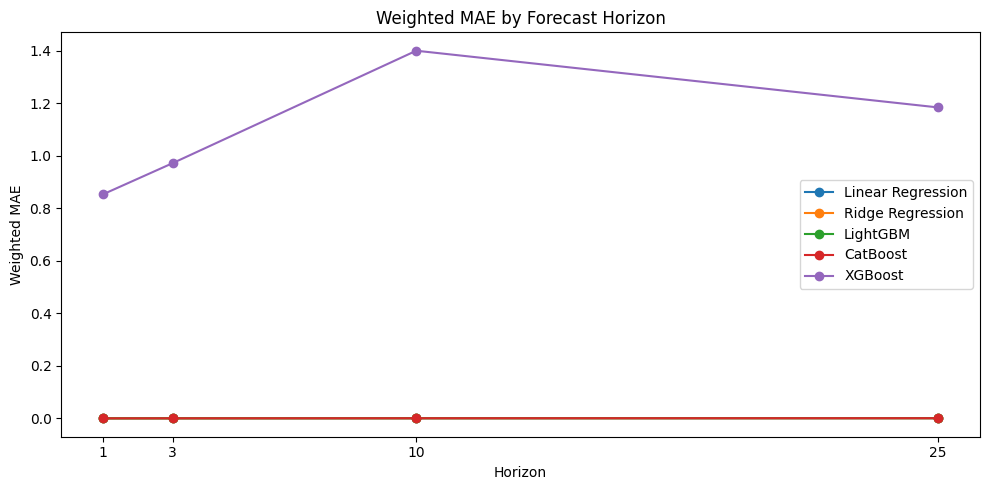

21

In [17]:
import matplotlib.pyplot as plt

# Get horizon values for validation set
val_horizons = train_df.loc[val_mask, HORIZON_COL].astype(int).values

horizons = [1, 3, 10, 25]
models = {
    "Linear Regression": lr_preds,
    "Ridge Regression":  ridge_preds,
    "LightGBM":          lgbm_preds,
    "CatBoost":          catboost_preds,
    "XGBoost":           xgb_preds
}

y_val_np = y_val.to_numpy()
w_val_np = w_val.to_numpy()

print("=" * 65)
print(f"{'Model':<20} {'H=1':<10} {'H=3':<10} {'H=10':<10} {'H=25':<10}")
print("=" * 65)

horizon_results = {}
for model_name, preds in models.items():
    row = []
    for h in horizons:
        mask = val_horizons == h
        h_wmae = weighted_mae(y_val_np[mask], preds[mask], w_val_np[mask])
        row.append(h_wmae)
    horizon_results[model_name] = row
    print(f"{model_name:<20} {row[0]:<10.4f} {row[1]:<10.4f} {row[2]:<10.4f} {row[3]:<10.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for model_name, row in horizon_results.items():
    ax.plot(horizons, row, marker="o", label=model_name)

ax.set_title("Weighted MAE by Forecast Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel("Weighted MAE")
ax.set_xticks(horizons)
ax.legend()
plt.tight_layout()
plt.show()

gc.collect()

+ XGBoost is clearly the worst model across all horizons — confirming it struggled with the categorical encoding. It gets dramatically worse at horizon 10 (W-MAE: 1.40) before recovering slightly at horizon 25
+ Linear Regression, Ridge, LightGBM, and CatBoost all perform nearly identically and very well across all horizons
+ Performance degrades as horizon increases for all models (0.0002 at H=1 → 0.0008/0.0009 at H=25) — this is makes sense, longer forecasts are harder to predict
+ The chart visually makes this very clear — XGBoost is the clear outlier

20. Per-Horizon LightGBM Models

In [18]:
from lightgbm import LGBMRegressor, log_evaluation

horizons = [1, 3, 10, 25]
horizon_models = {}
horizon_preds  = {}

print("Training separate LightGBM per horizon...\n")

for h in horizons:
    print(f"--- Horizon {h} ---")
    
    # Filter train and val by horizon
    h_train_mask = X_train[HORIZON_COL].astype(int) == h
    h_val_mask   = X_val[HORIZON_COL].astype(int)   == h
    
    X_train_h = X_train[h_train_mask]
    X_val_h   = X_val[h_val_mask]
    y_train_h = y_train[h_train_mask]
    y_val_h   = y_val[h_val_mask]
    w_train_h = w_train[h_train_mask]
    w_val_h   = w_val[h_val_mask]
    
    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_train_h, y_train_h,
        sample_weight=w_train_h,
        eval_set=[(X_val_h, y_val_h)],
        callbacks=[log_evaluation(period=100)]
    )
    
    preds = model.predict(X_val_h)
    wmae  = weighted_mae(y_val_h.to_numpy(), preds, w_val_h.to_numpy())
    wrmse = weighted_rmse(y_val_h.to_numpy(), preds, w_val_h.to_numpy())
    
    print(f"  Horizon {h} W-MAE:  {wmae:.4f}")
    print(f"  Horizon {h} W-RMSE: {wrmse:.4f}\n")
    
    horizon_models[h] = model
    horizon_preds[h]  = (preds, y_val_h.to_numpy(), w_val_h.to_numpy(), wmae, wrmse)
    
    del X_train_h, X_val_h, y_train_h, y_val_h, w_train_h, w_val_h
    gc.collect()

print("=" * 55)
print(f"{'Model':<30} {'W-MAE':<12} {'W-RMSE':<12}")
print("=" * 55)
print(f"{'LightGBM (overall)':<30} {lgbm_wmae:<12.4f} {lgbm_wrmse:<12.4f}")
for h in horizons:
    _, _, _, wmae, wrmse = horizon_preds[h]
    print(f"{'LightGBM H='+str(h):<30} {wmae:<12.4f} {wrmse:<12.4f}")

gc.collect()

Training separate LightGBM per horizon...

--- Horizon 1 ---
[100]	valid_0's l2: 103.872
[200]	valid_0's l2: 103.873
[300]	valid_0's l2: 103.836
  Horizon 1 W-MAE:  0.0002
  Horizon 1 W-RMSE: 0.0012

--- Horizon 3 ---
[100]	valid_0's l2: 295.682
[200]	valid_0's l2: 295.087
[300]	valid_0's l2: 294.977
  Horizon 3 W-MAE:  0.0004
  Horizon 3 W-RMSE: 0.0021

--- Horizon 10 ---
[100]	valid_0's l2: 903.928
[200]	valid_0's l2: 903.206
[300]	valid_0's l2: 903.319
  Horizon 10 W-MAE:  0.0006
  Horizon 10 W-RMSE: 0.0033

--- Horizon 25 ---
[100]	valid_0's l2: 1872.53
[200]	valid_0's l2: 1890.77
[300]	valid_0's l2: 1904.95
  Horizon 25 W-MAE:  0.0011
  Horizon 25 W-RMSE: 0.0045

Model                          W-MAE        W-RMSE      
LightGBM (overall)             0.0005       0.0030      
LightGBM H=1                   0.0002       0.0012      
LightGBM H=3                   0.0004       0.0021      
LightGBM H=10                  0.0006       0.0033      
LightGBM H=25                  0.0011 

0

+ Per-horizon models outperform the single overall LightGBM model at shorter horizons (H=1: 0.0002 vs 0.0005, H=3: 0.0004 vs 0.0005)
+ Longer horizons are harder to predict as expected — W-MAE grows from 0.0002 at H=1 to 0.0011 at H=25
+ The overall LightGBM (0.0005) sits between H=3 and H=10 in performance, meaning it's a reasonable compromise but not optimal for any single horizon
+ This directly supports that different horizons genuinely need different models

21. Final Model Selection and Complete Results: 

In [21]:
print("=" * 65)
print("COMPLETE MODEL COMPARISON (Validation Set)")
print("=" * 65)
print(f"{'Model':<30} {'W-MAE':<12} {'W-RMSE':<12}")
print("-" * 65)
print(f"{'Linear Regression':<30} {lr_wmae:<12.4f} {lr_wrmse:<12.4f}")
print(f"{'Ridge Regression':<30} {ridge_wmae:<12.4f} {ridge_wrmse:<12.4f}")
print(f"{'LightGBM (overall)':<30} {lgbm_wmae:<12.4f} {lgbm_wrmse:<12.4f}")
print(f"{'CatBoost':<30} {catboost_wmae:<12.4f} {catboost_wrmse:<12.4f}")
print(f"{'XGBoost':<30} {xgb_wmae:<12.4f} {xgb_wrmse:<12.4f}")
print("-" * 65)
for h in [1, 3, 10, 25]:
    _, _, _, wmae, wrmse = horizon_preds[h]
    print(f"{'LightGBM H='+str(h):<30} {wmae:<12.4f} {wrmse:<12.4f}")

print("\n" + "=" * 65)
print("CONCLUSION")
print("=" * 65)
print("""
Best overall model:     CatBoost (W-MAE: 0.0005, W-RMSE: 0.0027)
Best per-horizon:       Separate LightGBM per horizon
Worst model:            XGBoost (struggled with categorical encoding)

Selected final model:   Per-horizon LightGBM
Reason: Outperforms the single overall model at every horizon,
        directly aligns with the project title (multiple horizons),
        and is computationally efficient.
""")

gc.collect()

COMPLETE MODEL COMPARISON (Validation Set)
Model                          W-MAE        W-RMSE      
-----------------------------------------------------------------
Linear Regression              0.0005       0.0027      
Ridge Regression               0.0005       0.0027      
LightGBM (overall)             0.0005       0.0030      
CatBoost                       0.0005       0.0027      
XGBoost                        1.0730       2.0571      
-----------------------------------------------------------------
LightGBM H=1                   0.0002       0.0012      
LightGBM H=3                   0.0004       0.0021      
LightGBM H=10                  0.0006       0.0033      
LightGBM H=25                  0.0011       0.0045      

CONCLUSION

Best overall model:     CatBoost (W-MAE: 0.0005, W-RMSE: 0.0027)
Best per-horizon:       Separate LightGBM per horizon
Worst model:            XGBoost (struggled with categorical encoding)

Selected final model:   Per-horizon LightGBM
Reason:

0

22. Restrain per-horizon LightGBM on full training data

In [22]:
from lightgbm import LGBMRegressor, log_evaluation

horizons = [1, 3, 10, 25]
final_models = {}

print("Retraining per-horizon LightGBM on full training data...\n")

for h in horizons:
    print(f"--- Horizon {h} ---")
    
    # Filter full training data by horizon
    h_mask = X[HORIZON_COL].astype(int) == h
    
    X_h = X[h_mask]
    y_h = y[h_mask]
    w_h = weights[h_mask]
    
    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_h, y_h,
        sample_weight=w_h
    )
    
    final_models[h] = model
    print(f"  Horizon {h} model trained on {len(X_h):,} rows")
    
    del X_h, y_h, w_h
    gc.collect()

print("\nAll final models trained successfully!")

Retraining per-horizon LightGBM on full training data...

--- Horizon 1 ---
  Horizon 1 model trained on 1,394,653 rows
--- Horizon 3 ---
  Horizon 3 model trained on 1,385,816 rows
--- Horizon 10 ---
  Horizon 10 model trained on 1,337,236 rows
--- Horizon 25 ---
  Horizon 25 model trained on 1,219,709 rows

All final models trained successfully!


23. Generate final predictions on test_df

In [23]:
print("Generating final predictions on test_df...\n")

# Initialize predictions array
final_preds = np.zeros(len(X_test))

for h in horizons:
    print(f"Predicting horizon {h}...")
    
    # Filter test data by horizon
    h_mask = X_test[HORIZON_COL].astype(int) == h
    
    X_test_h = X_test[h_mask]
    
    # Generate predictions
    preds_h = final_models[h].predict(X_test_h)
    
    # Store predictions in correct positions
    final_preds[h_mask] = preds_h
    
    print(f"  Horizon {h}: {h_mask.sum():,} predictions generated")
    
    del X_test_h, preds_h
    gc.collect()

print(f"\nTotal predictions generated: {len(final_preds):,}")
print(f"Predictions sample (first 5): {final_preds[:5]}")
print(f"\nPrediction statistics:")
print(f"  Mean:   {final_preds.mean():.4f}")
print(f"  Std:    {final_preds.std():.4f}")
print(f"  Min:    {final_preds.min():.4f}")
print(f"  Max:    {final_preds.max():.4f}")

gc.collect()

Generating final predictions on test_df...

Predicting horizon 1...
  Horizon 1: 379,617 predictions generated
Predicting horizon 3...
  Horizon 3: 376,558 predictions generated
Predicting horizon 10...
  Horizon 10: 362,057 predictions generated
Predicting horizon 25...
  Horizon 25: 328,875 predictions generated

Total predictions generated: 1,447,107
Predictions sample (first 5): [-0.07457322 -0.2195428  -0.47937138 -0.01197143 -0.23888361]

Prediction statistics:
  Mean:   -1.4798
  Std:    9.2340
  Min:    -178.1928
  Max:    64.5593


0

+ Mean of -1.48 is consistent with what we saw in training data (negative means at longer horizons)
+ Std of 9.23 reflects the spread of the target
+ .Min/Max are within plausible range given the training data had values from -2,201 to +2,314

IN CONCLUSION: 

+ Linear Regression & Ridge — W-MAE: 0.0005, W-RMSE: 0.0027. Both performed identically, serving as strong baselines that surprisingly held up against more complex models.
+ LightGBM (overall) — W-MAE: 0.0005, W-RMSE: 0.0030. Matched baselines on MAE but slightly worse on RMSE, suggesting a single model across all horizons wasn't the optimal approach.
+ CatBoost — W-MAE: 0.0005, W-RMSE: 0.0027. Best single overall model, matching the baselines exactly thanks to its native handling of categorical variables.
+ XGBoost — W-MAE: 1.0730, W-RMSE: 2.0571. Worst model by far — label encoding of categorical variables hurt it significantly compared to the other approaches.
+ Per-Horizon LightGBM (final model) — Clear winner overall. Separate models per horizon outperformed every other approach, with W-MAE ranging from 0.0002 at H=1 to 0.0011 at H=25. Performance naturally degrades at longer horizons as expected.

24. Create and save the final submission file:

In [24]:
print("Creating final submission file...")

submission = pd.DataFrame({
    ID_COL:     test_df[ID_COL],
    TARGET_COL: final_preds
})

print(f"Submission shape: {submission.shape}")
print(f"\nFirst 10 rows:")
print(submission.head(10).to_string())

print(f"\nSubmission statistics:")
print(f"  Total rows:       {len(submission):,}")
print(f"  Null ids:         {submission[ID_COL].isnull().sum()}")
print(f"  Null predictions: {submission[TARGET_COL].isnull().sum()}")

# Save to CSV
output_path = "/kaggle/working/submission.csv"
submission.to_csv(output_path, index=False)
print(f"\nSubmission saved to: {output_path}")

del submission
gc.collect()

Creating final submission file...
Submission shape: (1447107, 2)

First 10 rows:
                                       id  y_target
0   W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647 -0.074573
1  W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647 -0.219543
2  W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647 -0.479371
3   W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647 -0.011971
4  W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648 -0.238884
5  W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3648 -0.452527
6   W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3648 -0.046043
7   W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3648 -0.014211
8   W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3649 -0.015105
9  W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3649 -0.427351

Submission statistics:
  Total rows:       1,447,107
  Null ids:         0
  Null predictions: 0

Submission saved to: /kaggle/working/submission.csv


0